In [9]:
import nest_asyncio
nest_asyncio.apply()

from pupil_labs.realtime_api.simple import discover_one_device
device = discover_one_device()

Exception ignored in: <async_generator object connect.__aiter__ at 0x77e30af896d0>
Traceback (most recent call last):
  File "/home/olhamelnyk/colcon_venv/venv/lib/python3.12/site-packages/pupil_labs/realtime_api/device.py", line 82, in status_updates
    break
RuntimeError: async generator ignored GeneratorExit


In [10]:
print(f"Phone IP address: {device.phone_ip}")
print(f"Phone name: {device.phone_name}")
print(f"Battery level: {device.battery_level_percent}%")
print(f"Free storage: {device.memory_num_free_bytes / 1024**3:.1f} GB")
print(f"Serial number of connected glasses: {device.serial_number_glasses}")

Phone IP address: 192.168.0.115
Phone name: OnePlus 6
Battery level: 99%
Free storage: 61.4 GB
Serial number of connected glasses: 83fpy


In [4]:
import cv2
import matplotlib.pyplot as plt


scene_sample, gaze_sample = device.receive_matched_scene_video_frame_and_gaze()

print("This sample contains the following data:\n")
print(f"Gaze x and y coordinates: {gaze_sample.x}, {gaze_sample.y}\n")
print(
    f"Pupil diameter in millimeters for the left eye: {gaze_sample.pupil_diameter_left} and the right eye: {gaze_sample.pupil_diameter_right}\n"
)
print(
    "Location of left and right eye ball centers in millimeters in relation to the scene camera of the Neon module."
)
print(
    f"For the left eye x, y, z: {gaze_sample.eyeball_center_left_x}, {gaze_sample.eyeball_center_left_y}, {gaze_sample.eyeball_center_left_z} and for the right eye x, y, z: {gaze_sample.eyeball_center_right_x}, {gaze_sample.eyeball_center_right_y}, {gaze_sample.eyeball_center_right_z}.\n"
)
print("Directional vector describing the optical axis of the left and right eye.")
print(
    f"For the left eye x, y, z: {gaze_sample.optical_axis_left_x}, {gaze_sample.optical_axis_left_y}, {gaze_sample.optical_axis_left_z} and for the right eye x, y, z: {gaze_sample.optical_axis_right_x}, {gaze_sample.optical_axis_right_y}, {gaze_sample.optical_axis_right_z}.\n"
)
print("Angles and aperture describing the eyelid openness of the left and right eye.")
print(
    f"For the left eye upper lid angle, lower lid angle, and aperture: {gaze_sample.eyelid_angle_top_left}, {gaze_sample.eyelid_angle_bottom_left}, {gaze_sample.eyelid_aperture_left} and for the right eye: {gaze_sample.eyelid_angle_top_right}, {gaze_sample.eyelid_angle_bottom_right}, {gaze_sample.eyelid_aperture_right}."
)

scene_image_rgb = cv2.cvtColor(scene_sample.bgr_pixels, cv2.COLOR_BGR2RGB)
plt.imshow(scene_image_rgb)
plt.scatter(gaze_sample.x, gaze_sample.y, s=200, facecolors="none", edgecolors="r")
device.close()
plt.show()

This sample contains the following data:

Gaze x and y coordinates: 669.2254638671875, 547.007568359375



AttributeError: 'GazeData' object has no attribute 'pupil_diameter_left'

This sample contains the following data:

Gaze x and y coordinates: 661.7023315429688, 547.3230590820312



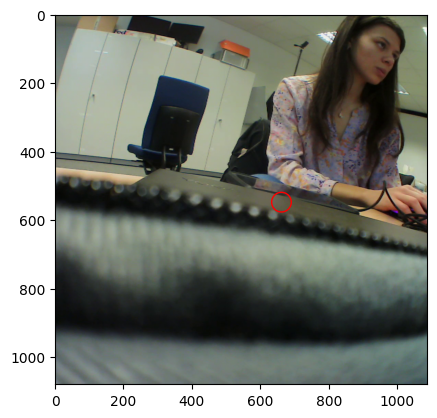

In [5]:
import cv2
import matplotlib.pyplot as plt
from pupil_labs.realtime_api.simple import discover_one_device



scene_sample, gaze_sample = device.receive_matched_scene_video_frame_and_gaze()

print("This sample contains the following data:\n")
print(f"Gaze x and y coordinates: {gaze_sample.x}, {gaze_sample.y}\n")

scene_image_rgb = cv2.cvtColor(scene_sample.bgr_pixels, cv2.COLOR_BGR2RGB)
plt.imshow(scene_image_rgb)
plt.scatter(gaze_sample.x, gaze_sample.y, s=200, facecolors="none", edgecolors="r")

device.close()
plt.show()

In [6]:
type(scene_sample)

pupil_labs.realtime_api.simple.models.SimpleVideoFrame

In [15]:
print("before receiving date from device")
            # Get data from device
 gaze_sample = device.receive_matched_scene_and_eyes_video_frames_and_gaze(10)
print("after receiving date from device")
            # Get current time for timestamp
print("This sample contains the following data:\n")
print(f"Gaze x and y coordinates: {gaze_sample.gaze.x}, {gaze_sample.gaze.y}\n")
scene_image_rgb = cv2.cvtColor(scene_sample.bgr_pixels, cv2.COLOR_BGR2RGB)
plt.imshow(scene_image_rgb)
plt.scatter(gaze_sample.x, gaze_sample.y, s=200, facecolors="none", edgecolors="r")
device.close()
plt.show()

before receiving date from device


TypeError: cannot unpack non-iterable NoneType object

In [3]:
import time

recording_id = device.recording_start()
print(f"Started recording with id {recording_id}")

time.sleep(5)

device.recording_stop_and_save()

Started recording with id afb7a145-5fab-4c84-9069-b1d18ea80ba1


In [4]:
device.recording_start()

print(device.send_event("test event 1"))

time.sleep(5)

# send event with current timestamp
print(device.send_event("test event 2", event_timestamp_unix_ns=time.time_ns()))

device.recording_stop_and_save()

Event(name=None recording_id=None timestamp_unix_ns=1747301425493000000 datetime=2025-05-15 11:30:25.493000)
Event(name=None recording_id=97bce744-7c7a-4f3c-a7cf-74d32021f684 timestamp_unix_ns=1747301438527737779 datetime=2025-05-15 11:30:38.527738)


In [5]:
!pip install -U matplotlib


In [5]:
from datetime import datetime
import matplotlib.pyplot as plt
import cv2

scene_sample = device.receive_scene_video_frame()

dt = datetime.fromtimestamp(scene_sample.timestamp_unix_seconds)
print(f"This scene camera image was recorded at {dt}")

# matplotlib expects images to be in RGB rather than BGR.
# Thus we use OpenCv to convert color spaces.
scene_image_rgb = cv2.cvtColor(scene_sample.bgr_pixels, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 10))
plt.imshow(scene_image_rgb)

ModuleNotFoundError: No module named 'cv2'

In [20]:
gaze_sample = device.receive_gaze_datum()

dt = datetime.fromtimestamp(gaze_sample.timestamp_unix_seconds)
print(f"This gaze sample was recorded at {dt}")

plt.figure(figsize=(10, 10))
plt.scatter(gaze_sample.x, gaze_sample.y, s=2000, facecolors='none', edgecolors='r')
plt.xlim(0, 1088)
plt.ylim(1080, 0)

This gaze sample was recorded at 2025-05-15 11:21:46.826063


NameError: name 'plt' is not defined

In [28]:
from pupil_labs.realtime_api.simple import discover_one_device
import nest_asyncio
nest_asyncio.apply()
# Look for devices. Returns as soon as it has found the first device.
print("Looking for the next best device...")
#device = discover_one_device(max_search_duration_seconds=10)
if device is None:
    raise SystemExit("No device found.")

estimate = device.estimate_time_offset()
if estimate is None:
    device.close()
    raise SystemExit("Pupil Companion app is too old")

print(f"Mean time offset: {estimate.time_offset_ms.mean} ms")
print(f"Mean roundtrip duration: {estimate.roundtrip_duration_ms} ms")

device.close()

Looking for the next best device...
Mean time offset: 25000.62 ms
Mean roundtrip duration: Estimate(#samples=100, mean±std=1.550±0.539ms, median=2.0ms) ms
